Statistical project to analyze timeseries of stock returns

initial stock analyzed is Apple

In [28]:
# imports
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels
from scipy.stats import genpareto, probplot

In [29]:
# Choose asset
ticker = "AAPL"

# Download daily data
df = yf.download(ticker, start="2005-01-01", progress=True)


[*********************100%***********************]  1 of 1 completed


In [30]:
df['pct-returns'] = df['Close'].pct_change()
df['log-returns'] = np.log(df['Close']).diff()

In [31]:
# Autocorrelation 
mean_return = np.mean(df['pct-returns'])
def autocorr(ticker_data=df, lag=1):
    ticker_data['pct-returns'] = ticker_data['pct-returns'].dropna()
    mean_return = np.mean(ticker_data['pct-returns'])
    cov_sum = 0
    var_sum = 0
    for t in range(lag, len(ticker_data['pct-returns'])):
        cov_sum += (ticker_data['pct-returns'].iloc[t] - mean_return) * (ticker_data['pct-returns'].iloc[t-lag] - mean_return)
    for t in range(0, len(ticker_data['pct-returns'])):
        var_sum += (ticker_data['pct-returns'].iloc[t] - mean_return) ** 2

    return cov_sum / var_sum


In [32]:
df.head()

Price,Close,High,Low,Open,Volume,pct-returns,log-returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2005-01-03,0.948180,0.975446,0.937842,0.970502,691992000,NaN,NaN
2005-01-04,0.957918,0.980839,0.943386,0.955671,1096810400,0.010271,0.010218
2005-01-05,0.966307,0.977543,0.959565,0.965707,680433600,0.008758,0.008719
2005-01-06,0.967056,0.972449,0.948779,0.968853,705555200,0.000775,0.000775
2005-01-07,1.037469,1.043162,0.970052,0.973798,2227450400,0.072811,0.070283


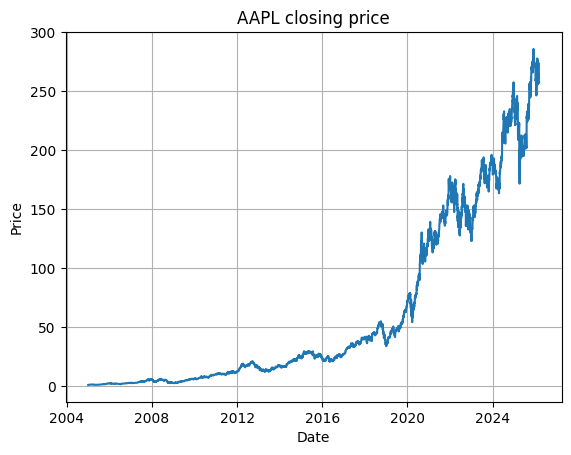

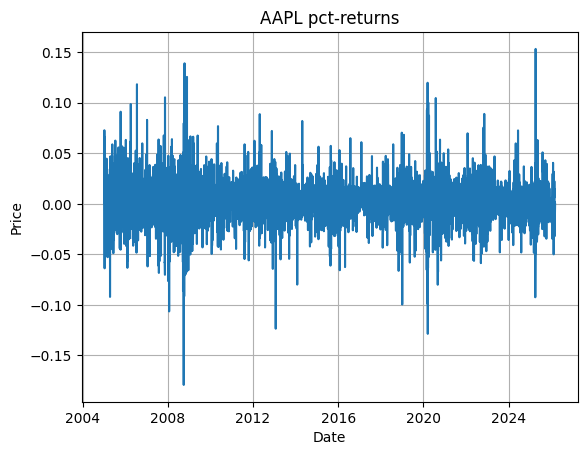

In [33]:
# Plotting closing price
plt.figure()
plt.plot(df.index, df["Close"])
plt.title(f"{ticker} closing price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df.index, df["pct-returns"])
plt.title(f"{ticker} pct-returns")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# plt.figure()
# plt.plot(df.index, df["log-returns"])
# plt.title(f"{ticker} log-returns")
# plt.xlabel("Date")
# plt.ylabel("Price")
# plt.grid(True)
# plt.show()


Autocorrelation:
for r --> autocorrelation in mean
for r^2 --> variance
for |r| --> volatility
 

<Figure size 640x480 with 0 Axes>

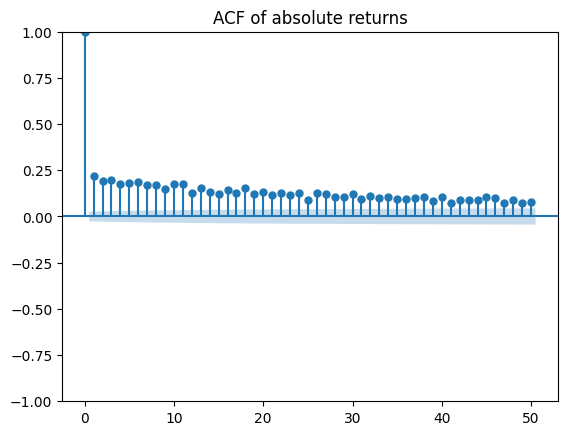

In [34]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

r = df["pct-returns"].dropna()
r_abs = np.abs(df["pct-returns"].dropna())
r_2 = np.pow(df["pct-returns"].dropna(), 2)

# plt.figure()
# plot_acf(r, lags=50)
# plt.title("ACF of r")
# plt.show()

# plt.figure()
# plot_acf(r_2, lags=50)
# plt.title("ACF of squared returns")
# plt.show()

plt.figure()
plot_acf(r_abs, lags=50)
plt.title("ACF of absolute returns")
plt.show()


Ljung-Box for r^2 showing p-values < 0.05 indicates autocorrelation (volatility clustering).
"The probability of observing this much autocorrelation in squared returns if variance were constant is very small or extremely small."

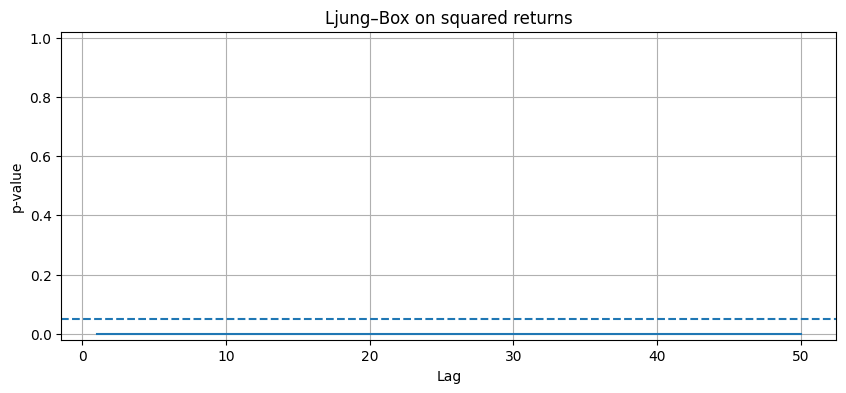

In [35]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def ljung_box_plot(series, max_lag=50, title="Ljung–Box p-values"):
    """
    Plot Ljung–Box p-values for lags 1..max_lag.
    Interpretation:
      - small p-values (e.g. < 0.05) => reject 'no autocorrelation' up to that lag.
    """
    x = pd.Series(series).dropna().astype(float)

    # returns DataFrame with columns: lb_stat, lb_pvalue
    res = acorr_ljungbox(x, lags=range(1, max_lag + 1), return_df=True)

    plt.figure(figsize=(10, 4))
    plt.plot(res.index, res["lb_pvalue"])
    plt.axhline(0.05, linestyle="--")  # significance line
    plt.title(title)
    plt.xlabel("Lag")
    plt.ylabel("p-value")
    plt.ylim(-0.02, 1.02)
    plt.grid(True)
    plt.show()

    pass

# Example usage (assuming you already have a Series r of returns)
r = df["pct-returns"].dropna()

# # 1) Mean dependence test
# ljung_box_plot(r, max_lag=50, title="Ljung–Box on returns")

# 2) Volatility clustering test
ljung_box_plot(np.pow(r, 2), max_lag=50, title="Ljung–Box on squared returns")

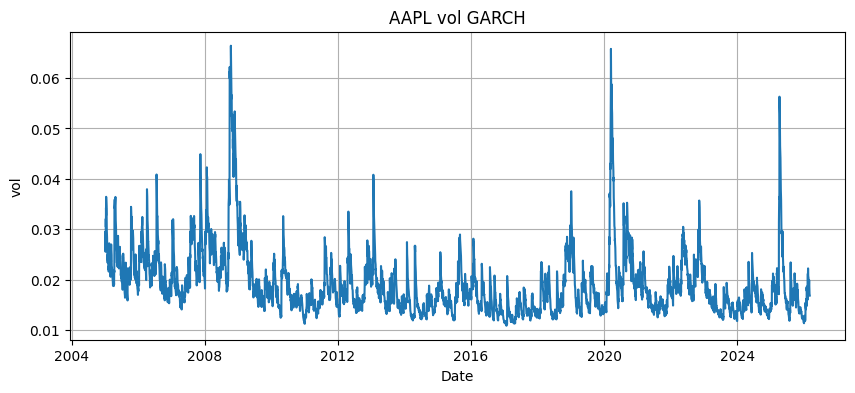

In [36]:
# Calculating volatility to normalize for vol.

from arch import arch_model

model = arch_model(r * 100, vol="GARCH", p=1, q=1, mean="Zero")
res = model.fit(disp="off")

# print(res.summary())

sigma = res.conditional_volatility / 100
# print(sigma)

plt.figure(figsize = (10, 4))
plt.plot(sigma)
plt.title(f"{ticker} vol GARCH")
plt.xlabel("Date")
plt.ylabel("vol")
plt.grid(True)
plt.show()



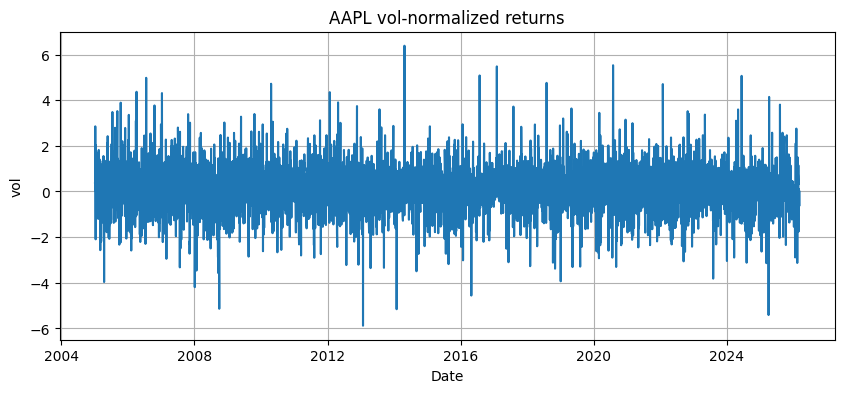

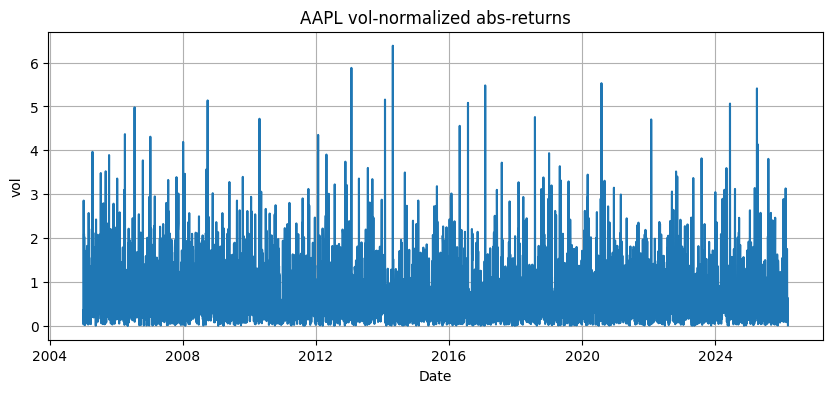

In [37]:
# vol-normalized returns

z = r/sigma
z_abs = np.abs(z)

plt.figure(figsize = (10, 4))
plt.plot(z)
plt.title(f"{ticker} vol-normalized returns")
plt.xlabel("Date")
plt.ylabel("vol")
plt.grid(True)
plt.show()

plt.figure(figsize = (10, 4))
plt.plot(z_abs)
plt.title(f"{ticker} vol-normalized abs-returns")
plt.xlabel("Date")
plt.ylabel("vol")
plt.grid(True)
plt.show()

<Figure size 640x480 with 0 Axes>

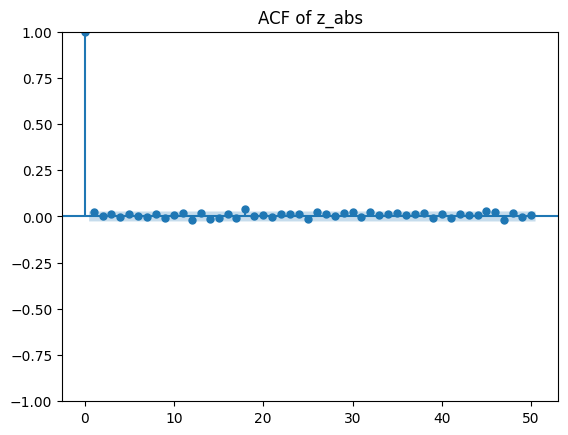

In [38]:
# plt.figure()
# plot_acf(z, lags=50)
# plt.title("ACF of z")
# plt.show()

plt.figure()
plot_acf(z_abs, lags=50)
plt.title("ACF of z_abs")
plt.show()

# plt.figure()
# plot_acf(np.pow(z, 2), lags=50)
# plt.title("ACF of z_2")
# plt.show()


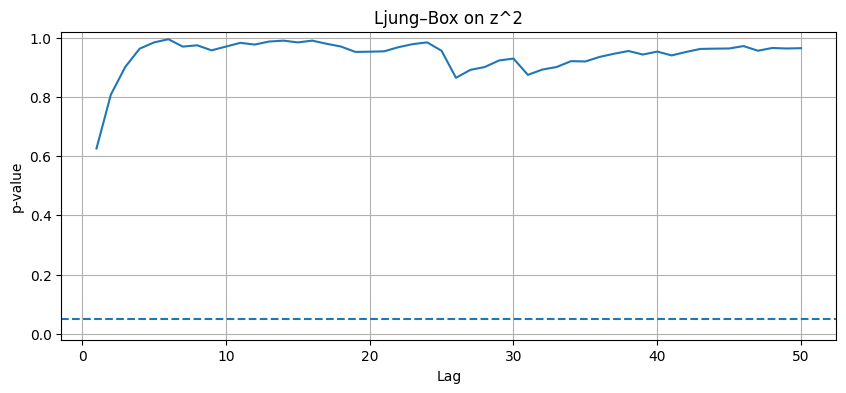

In [39]:
# Ljung-Box on z and z_abs

# ljung_box_plot(z, max_lag=50, title="Ljung–Box on z")
# ljung_box_plot(z_abs, max_lag=50, title="Ljung–Box on z_abs")
ljung_box_plot(np.pow(z, 2), max_lag=50, title="Ljung–Box on z^2")

In [40]:
# Mean residual life plot

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_mrl_with_ci(data, thresholds=None, conf_level=0.95):
    """
    Plots the Mean Residual Life (MRL) plot with asymptotic confidence intervals.
    
    Parameters:
    data (array-like): The loss data or negative returns.
    thresholds (array-like): Thresholds to evaluate. If None, auto-generates them.
    conf_level (float): Confidence level for the intervals (default 0.95).
    """
    data = np.asarray(data)
    data = data[np.isfinite(data)] # Clean NaN values just like in your script
    
    if thresholds is None:
        # Default to checking between the 50th and 98th percentiles
        thresholds = np.linspace(np.percentile(data, 50), np.percentile(data, 98), 250)

    # z-value is about 1.96: 
    z = norm.ppf((1 + conf_level) / 2)
    
    mrl = []
    ci_lower = []
    ci_upper = []
    valid_u = []
    
    for u in thresholds:
        exceedances = data[data > u] - u
        Nu = len(exceedances)
        
        # Need at least a few points to calculate standard deviation
        if Nu > 2: 
            mean_excess = np.mean(exceedances)
            std_excess = np.std(exceedances, ddof=1)
            
            # Standard error of the mean
            se = std_excess / np.sqrt(Nu)
            margin = z * se
            
            valid_u.append(u)
            mrl.append(mean_excess)
            ci_lower.append(mean_excess - margin)
            ci_upper.append(mean_excess + margin)
            
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(valid_u, mrl, marker='o', markersize=4, linestyle='-', color='blue', label='Mean Excess')
    plt.plot(valid_u, ci_upper, linestyle='--', color='gray', label=f'{int(conf_level*100)}% CI')
    plt.plot(valid_u, ci_lower, linestyle='--', color='gray')
    
    # Optional: fill the interval area
    plt.fill_between(valid_u, ci_lower, ci_upper, color='gray', alpha=0.2)
    
    plt.title('Mean Residual Life Plot')
    plt.xlabel('Threshold (u)')
    plt.ylabel('Mean Excess')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Example Usage ---
# Assuming L_clean is your array of negative log-returns (losses)
plot_mrl_with_ci(L)



NameError: name 'L' is not defined

In [ ]:
L = (-z).dropna()

def mean_excess_plot(x, u_grid):
    x = np.asarray(x)
    me = []
    exceedances = []
    for u in u_grid:
        exc = x[x > u] - u
        exceedances.append(len(exc))
        me.append(np.nan if len(exc)==0 else exc.mean())
    return np.array(me), np.array(exceedances)

u_grid = np.quantile(L, np.linspace(0.90, 0.99, 50))
# u_grid = np.linspace(np.quantile(L, 0.9), np.quantile(L, 0.9975), 250)

me, num = mean_excess_plot(L, u_grid)

plt.figure(figsize=(10,4))
plt.plot(u_grid, me)
plt.title("Mean Residual Life (Mean Excess) Plot for Losses")
plt.xlabel("Threshold u")
plt.ylabel("Mean excess E[L-u | L>u]")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
# plt.plot(u_grid, num/len(L))
plt.plot(u_grid, num)
plt.title("number of exceedances over threshold")
plt.xlabel("Threshold u")
plt.ylabel("number of exceedances over u")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(u_grid, num/len(L))
# plt.plot(u_grid, num)
plt.title("number of exceedances over threshold")
plt.xlabel("Threshold u")
plt.ylabel("number of exceedances over u")
plt.grid(True)
plt.show()


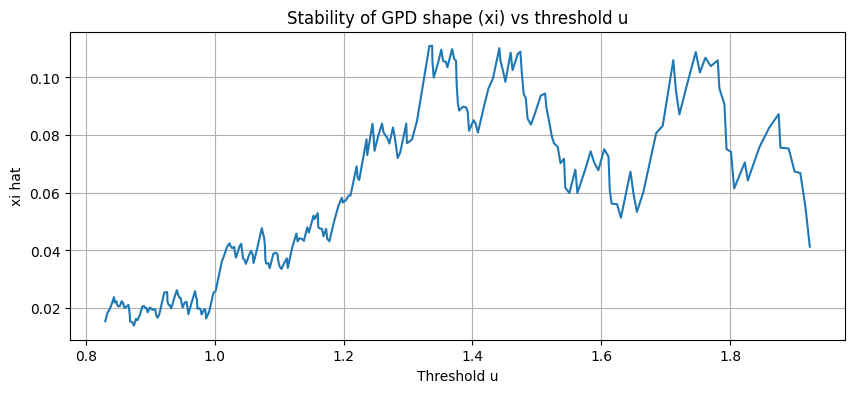

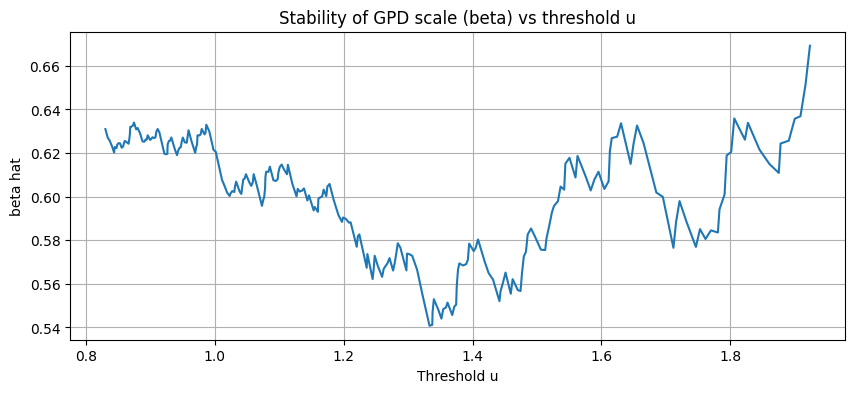

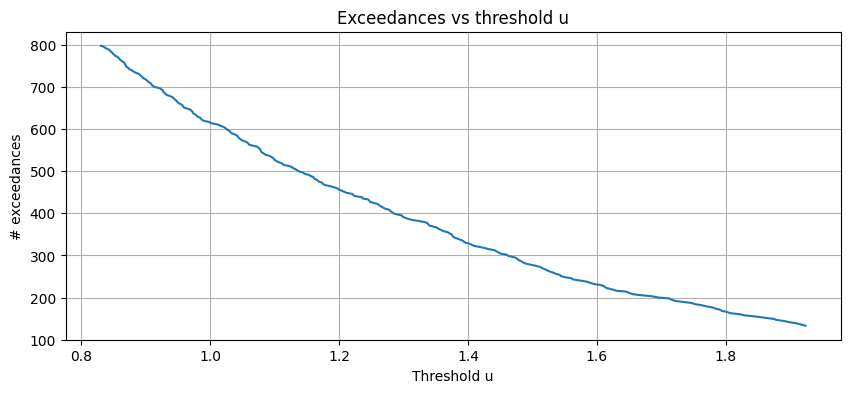

In [ ]:
u_grid = np.quantile(L, np.linspace(0.85, 0.975, 250))

xis, betas, nums = [], [], []

for u in u_grid:
    exc = L[L > u] - u
    nums.append(len(exc))
    if len(exc) < 80:
        xis.append(np.nan); betas.append(np.nan)
        continue
    xi, loc, beta = genpareto.fit(exc, floc=0)
    xis.append(xi); betas.append(beta)


plt.figure(figsize=(10,4))
plt.plot(u_grid, xis)
plt.title("Stability of GPD shape (xi) vs threshold u")
plt.xlabel("Threshold u")
plt.ylabel("xi hat")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(u_grid, betas)
plt.title("Stability of GPD scale (beta) vs threshold u")
plt.xlabel("Threshold u")
plt.ylabel("beta hat")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(u_grid, nums)
plt.title("Exceedances vs threshold u")
plt.xlabel("Threshold u")
plt.ylabel("# exceedances")
plt.grid(True)
plt.show()


--- Optimization Complete ---
Optimal Threshold (u): 1.3788
Number of Tail Events: 342
Minimum AD Score:      0.0874


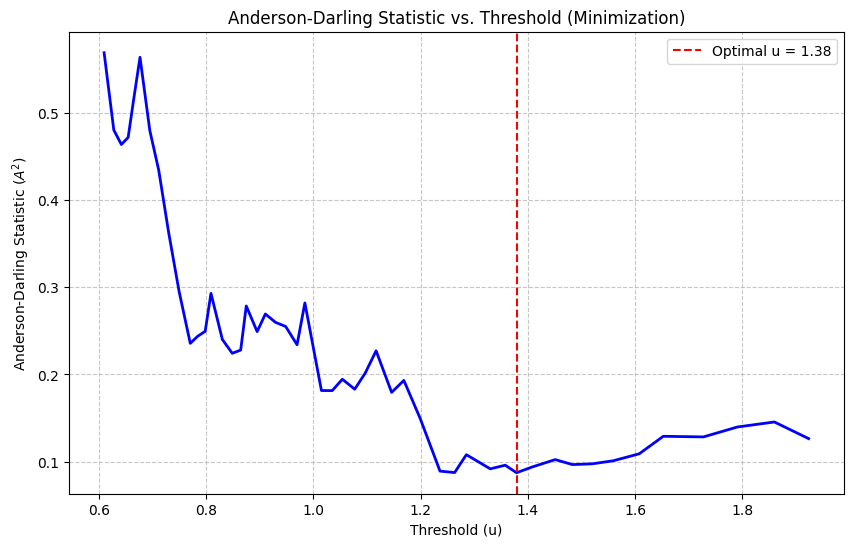

In [ ]:
# (We stop at 96% to ensure we don't drop below ~200 data points)
percentiles = np.linspace(80, 97.5, 50)
thresholds = np.percentile(L, percentiles)

ad_scores = []
valid_thresholds = []
n_exceedances = []

# --- 3. The Anderson-Darling Loop ---
for u in thresholds:
    # Get exceedances
    exceedances = L[L > u] - u
    n = len(exceedances)
    
    # Safety check: require at least 50 points for a stable GPD fit
    if n < 50:
        continue
        
    # Fit the GPD
    shape, loc, scale = genpareto.fit(exceedances, floc=0)
    
    # Sort the data (required for the AD formula)
    x_sorted = np.sort(exceedances)
    
    # Calculate the theoretical CDF values for our data points
    # We clip the upper bound slightly below 1 to prevent log(0) errors in the math
    cdf_vals = genpareto.cdf(x_sorted, c=shape, loc=0, scale=scale)
    cdf_vals = np.clip(cdf_vals, 1e-10, 1 - 1e-10) 
    
    # Calculate the Anderson-Darling A^2 statistic mathematically
    i = np.arange(1, n + 1)
    
    # To only punish right tail errors we use the following ad_stat
    term1 = n/2.0
    term2 = -2.0 * np.sum(cdf_vals)
    term3 = -np.sum((2.0 - (2.0*i - 1.0) / n) * np.log(1.0 - cdf_vals))

    ad_stat = term1 + term2 + term3

    # # Regular AD-formula to punish errors in both tails.
    # ad_stat = -n - np.sum((2 * i - 1) * (np.log(cdf_vals) + np.log(1 - cdf_vals[::-1])) / n)
    
    ad_scores.append(ad_stat)
    valid_thresholds.append(u)
    n_exceedances.append(n)

# --- 4. Find the Optimal Threshold ---
# The best threshold is the one that minimizes the AD statistic
best_idx = np.argmin(ad_scores)
optimal_u = valid_thresholds[best_idx]
optimal_n = n_exceedances[best_idx]
min_ad = ad_scores[best_idx]

print(f"--- Optimization Complete ---")
print(f"Optimal Threshold (u): {optimal_u:.4f}")
print(f"Number of Tail Events: {optimal_n}")
print(f"Minimum AD Score:      {min_ad:.4f}")

# --- 5. Plot the Optimization Curve ---
plt.figure(figsize=(10, 6))
plt.plot(valid_thresholds, ad_scores, color='blue', linewidth=2)
plt.axvline(optimal_u, color='red', linestyle='--', label=f'Optimal u = {optimal_u:.2f}')
plt.title('Anderson-Darling Statistic vs. Threshold (Minimization)')
plt.xlabel('Threshold (u)')
plt.ylabel('Anderson-Darling Statistic ($A^2$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()




Optimal threshold u:   1.3500
Exceedances N:         414
Fitted Shape (xi):     0.1569
Fitted Scale (sigma):  0.5675


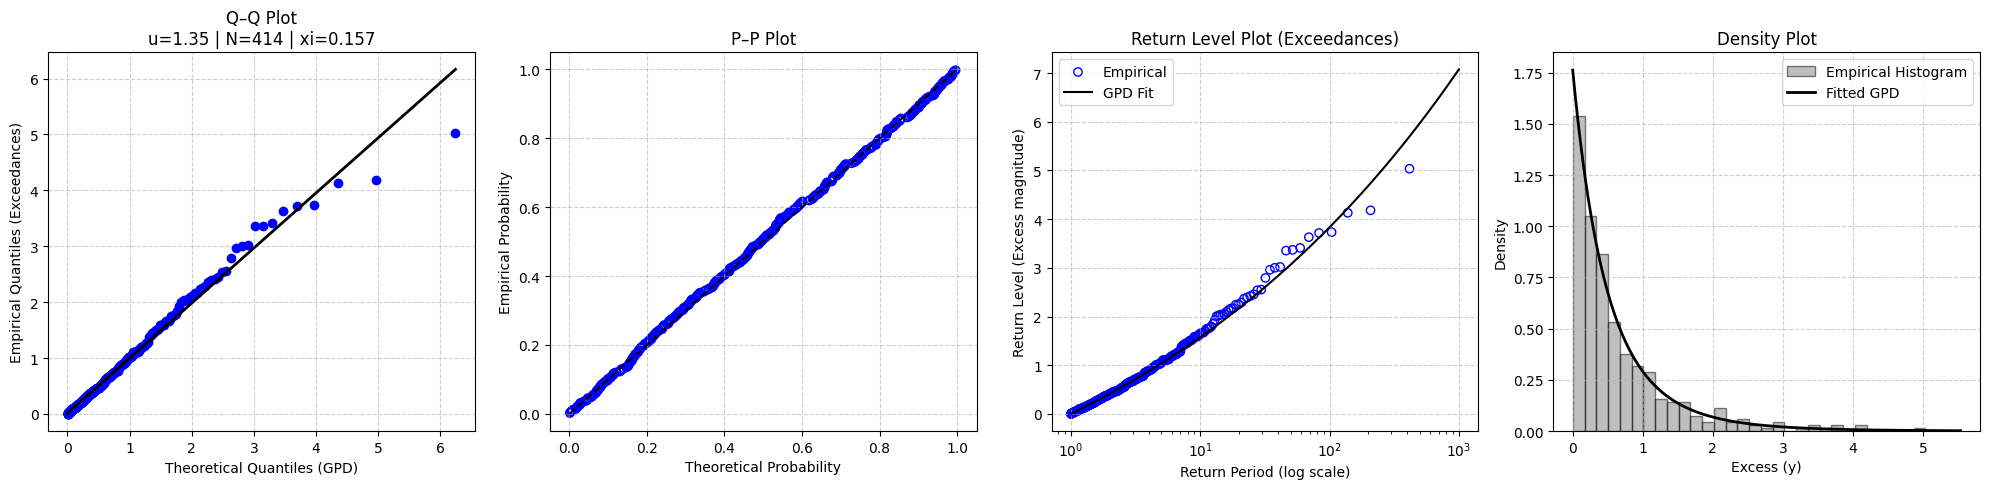

In [43]:
# ==========================================
# 1. PREPARE DATA AT OPTIMAL THRESHOLD
# ==========================================
u = 1.35  # <-- use your computed optimal_u
data = z[z > u] - u
data = data[np.isfinite(data)]
# data = L[np.isfinite(L)]

n = len(data)
if n < 50:
    print(f"Warning: only {n} exceedances above optimal_u={u:.4f}. Fits/plots may be unstable.")

# ==========================================
# 2. FIT THE MODEL ONCE
# ==========================================
shape, loc, scale = genpareto.fit(data, floc=0)

print(f"Optimal threshold u:   {u:.4f}")
print(f"Exceedances N:         {n}")
print(f"Fitted Shape (xi):     {shape:.4f}")
print(f"Fitted Scale (sigma):  {scale:.4f}")

sorted_data = np.sort(data)
empirical_p = np.arange(1, n + 1) / (n + 1)

# ==========================================
# 3. CREATE THE DASHBOARD (4 plots)
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# --- PLOT 1: Q–Q plot (like your first code, but for optimal_u only) ---
ax = axes[0]
probplot(data, dist=genpareto, sparams=(shape, 0, scale), plot=ax)

# Make the reference line thicker/red if it exists
lines = ax.get_lines()
if len(lines) >= 2:
    lines[1].set_color("black")
    lines[1].set_linewidth(2)

ax.set_title(f"Q–Q Plot\nu={u:.2f} | N={n} | xi={shape:.3f}")
ax.set_xlabel("Theoretical Quantiles (GPD)")
ax.set_ylabel("Empirical Quantiles (Exceedances)")
ax.grid(True, linestyle="--", alpha=0.6)

# --- PLOT 2: P–P plot ---
ax = axes[1]
theoretical_p = genpareto.cdf(sorted_data, c=shape, loc=0, scale=scale)
theoretical_p = np.clip(theoretical_p, 1e-12, 1 - 1e-12)

ax.scatter(theoretical_p, empirical_p, facecolors='none', edgecolors='b')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_title("P–P Plot")
ax.set_xlabel("Theoretical Probability")
ax.set_ylabel("Empirical Probability")
ax.grid(True, linestyle="--", alpha=0.6)

# --- PLOT 3: Return level plot (EXCESS magnitude, consistent with your second code) ---
ax = axes[2]
empirical_return_periods = 1 / (1 - empirical_p)

m_range = np.logspace(np.log10(1.01), np.log10(1000), 200)
theoretical_return_levels = genpareto.ppf(1 - 1/m_range, c=shape, loc=0, scale=scale)

ax.scatter(empirical_return_periods, sorted_data, facecolors='none', edgecolors='b', label='Empirical')
ax.plot(m_range, theoretical_return_levels, 'k-', label='GPD Fit')
ax.set_xscale('log')
ax.set_title("Return Level Plot (Exceedances)")
ax.set_xlabel("Return Period (log scale)")
ax.set_ylabel("Return Level (Excess magnitude)")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()

# --- PLOT 4: Density plot ---
ax = axes[3]
ax.hist(data, bins=30, density=True, alpha=0.5, color='gray', edgecolor='black', label='Empirical Histogram')

x_range = np.linspace(0, max(data) * 1.1 if len(data) else 1, 300)
theoretical_pdf = genpareto.pdf(x_range, c=shape, loc=0, scale=scale)
ax.plot(x_range, theoretical_pdf, 'black', lw=2, label='Fitted GPD')

ax.set_title("Density Plot")
ax.set_xlabel("Excess (y)")
ax.set_ylabel("Density")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()

plt.tight_layout()
plt.savefig("gpd_diagnostics_optimal_u.png", dpi=200)
plt.show()


In [ ]:
def pot_var_es(u, xi, beta, p_u, alpha):
    """
    POT/GPD VaR and ES for losses L.
    Assumes: exceedances Y = L-u | L>u ~ GPD(xi, beta) with loc=0.
    p_u = P(L>u) ~ Nu/N.
    alpha = confidence level (e.g. 0.99).
    """
    tail_prob = 1.0 - alpha  # P(L > VaR_alpha)

    # VaR formula (quantile for L)
    if abs(xi) < 1e-10:
        var = u + beta * np.log(p_u / tail_prob)
    else:
        var = u + (beta / xi) * ((p_u / tail_prob) ** xi - 1.0)

    # ES exists only if xi < 1
    if xi >= 1:
        es = np.nan
    else:
        es = (var + beta - xi * u) / (1.0 - xi)

    return var, es

# --- Inputs from your fitted model ---
u = optimal_u
xi = shape      # rename if you used "shape"
beta = scale    # rename if you used "scale"

L_clean = np.asarray(L)
L_clean = L_clean[np.isfinite(L_clean)]
N = len(L_clean)
Nu = np.sum(L_clean > u)
p_u = Nu / N

investment = 1_000_000
alphas = [0.95, 0.975, 0.99, 0.995]

rows = []
for a in alphas:
    var_a, es_a = pot_var_es(u, xi, beta, p_u, a)
    rows.append((a, var_a, es_a, investment * var_a, investment * es_a))

print(f"N={N}, threshold u={u:.6f}, Nu={Nu}, p_u={p_u:.6f}, xi={xi:.5f}, beta={beta:.5f}\n")

print(f"{'alpha':>7} | {'VaR (loss)':>12} | {'ES (loss)':>12} | {'VaR (loss)':>14} | {'ES (money)':>14}")
print("-"*70)
for a, var_l, es_l, var_m, es_m in rows:
    print(f"{a:7.3f} | {var_l:12.6f} | {es_l:12.6f} | {var_m:14.2f} | {es_m:14.2f}")






N=5320, threshold u=1.378833, Nu=342, p_u=0.064286, xi=0.16320, beta=0.56544

  alpha |   VaR (loss) |    ES (loss) |     VaR (loss) |     ES (money)
----------------------------------------------------------------------
  0.950 |     1.523892 |     2.227904 |     1523891.74 |     2227903.72
  0.975 |     1.956229 |     2.744560 |     1956228.51 |     2744559.56
  0.990 |     2.608216 |     3.523705 |     2608216.46 |     3523705.37
  0.995 |     3.170422 |     4.195559 |     3170422.12 |     4195558.56
